# Token-level bound figures

Visualizes results of the token-level Bretagnolle-Huber / Pinsker bound experiment (`compute_token_bound.py`). Does not recompute anything -- reads the three existing CSVs in this folder. Reuses the shared color palette / save convention from `plotting_style.py` (originally defined in `figures/figure_plotting.ipynb`).

In [33]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

ROOT = Path.cwd().parent if Path.cwd().name == "token_level" else Path.cwd()
sys.path.insert(0, str(ROOT))

from plotting_style import COLOR_BH, COLOR_PINSKER, PALETTE_N_MEMBERS, apply_style, save_fig

apply_style()

TOKEN_LEVEL_DIR = ROOT / "token_level"
OUT_DIR = TOKEN_LEVEL_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CAPTION_NOTE = "m=200 samples, seq_len_cap=128, seed=0 (single seed, pilot scope)"

print(f"ROOT             = {ROOT}")
print(f"TOKEN_LEVEL_DIR  = {TOKEN_LEVEL_DIR}")
print(f"OUT_DIR          = {OUT_DIR}")


ROOT             = c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs
TOKEN_LEVEL_DIR  = c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level
OUT_DIR          = c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures


## Inspection

Load all three CSVs, print schema/summary, and confirm (against the real data, not assumed) the filename-to-n_members mapping, the saturation of `bh_seq_hat` / `tok_bound_hat_capped`, the Pinsker/BH crossover fraction, and the per-position decay shape.

In [34]:
bounds_path = TOKEN_LEVEL_DIR / "token_level_bounds.csv"
pos_path_2000_named = TOKEN_LEVEL_DIR / "token_level_bounds_per_position_N200_ep20.csv"
pos_path_6000_named = TOKEN_LEVEL_DIR / "token_level_bounds_per_position_N600_ep20.csv"

bounds = pd.read_csv(bounds_path)

print("=" * 78)
print(f"token_level_bounds.csv  <-  {bounds_path}")
bounds.info()
print(bounds.describe())
for col in ["seed", "n_members", "epochs"]:
    print(f"  unique {col}: {sorted(bounds[col].unique().tolist())}")
print()
print(bounds.to_string(index=False))


token_level_bounds.csv  <-  c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\token_level_bounds.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  12 non-null     int64  
 1   n_members             12 non-null     int64  
 2   epochs                12 non-null     int64  
 3   m_samples             12 non-null     int64  
 4   seq_len_cap           12 non-null     int64  
 5   kl_seq_hat            12 non-null     float64
 6   bh_seq_hat            12 non-null     float64
 7   pinsker_seq_hat       12 non-null     float64
 8   kl_tok_hat            12 non-null     float64
 9   tok_bound_hat         12 non-null     float64
 10  tok_bound_hat_capped  12 non-null     float64
 11  adv_ref_existing      12 non-null     float64
dtypes: float64(7), int64(5)
memory usage: 1.3 KB
       seed    n_

In [35]:
pos_raw = {
    "N200_ep20": pd.read_csv(pos_path_2000_named),
    "N600_ep20": pd.read_csv(pos_path_6000_named),
}

for label, df in pos_raw.items():
    print("=" * 78)
    print(f"{label}.csv")
    df.info()
    print(df.describe())
    print(f"  sample_index: {df['sample_index'].nunique()} unique, "
          f"range [{df['sample_index'].min()}, {df['sample_index'].max()}]")
    print(f"  position_t:   {df['position_t'].nunique()} unique, "
          f"range [{df['position_t'].min()}, {df['position_t'].max()}]")
    print()


N200_ep20.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sample_index  25600 non-null  int64  
 1   position_t    25600 non-null  int64  
 2   kl_t          25600 non-null  float64
 3   bh_t          25600 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 800.1 KB
       sample_index    position_t          kl_t          bh_t
count  25600.000000  25600.000000  25600.000000  25600.000000
mean      99.500000     64.500000      2.803301      0.893187
std       57.735433     36.950011      1.722235      0.177259
min        0.000000      1.000000      0.000177      0.013294
25%       49.750000     32.750000      1.599142      0.893269
50%       99.500000     64.500000      2.660028      0.964393
75%      149.250000     96.250000      3.759922      0.988289
max      199.000000    128.000000     17.478357      1.000000
  sample_i

In [36]:
# Filename -> n_members mapping: don't trust the "N200"/"N600" filename literally --
# cross-check against kl_tok_hat in token_level_bounds.csv (mean summed KL over T=128
# positions), which is computed independently by compute_token_bound.py.
bounds_e20 = bounds[bounds["epochs"] == 20].set_index("n_members")["kl_tok_hat"]

print("Filename -> n_members cross-check (epoch=20, seed=0):")
file_to_n = {}
for label, df in pos_raw.items():
    per_sample_kl_sum = df.groupby("sample_index")["kl_t"].sum().mean()
    best_n = int((bounds_e20 - per_sample_kl_sum).abs().idxmin())
    diff = abs(bounds_e20.loc[best_n] - per_sample_kl_sum)
    file_to_n[label] = best_n
    print(f"  {label}: mean per-sample sum(kl_t) = {per_sample_kl_sum:.4f}  "
          f"-> matches n_members={best_n} (kl_tok_hat={bounds_e20.loc[best_n]:.4f}, |diff|={diff:.4f})")

assert file_to_n == {"N200_ep20": 2000, "N600_ep20": 6000}, (
    f"Filename->n_members mapping does not match the assumed convention: {file_to_n}. "
    "STOP -- do not proceed with the prompt's assumed mapping."
)
print(f"\nConfirmed: N200_ep20 -> n_members=2000, N600_ep20 -> n_members=6000 "
      f"(both epochs=20, seed=0). Using explicit n_members from here on, not filenames.")

per_position = pd.concat(
    [df.assign(n_members=file_to_n[label]) for label, df in pos_raw.items()],
    ignore_index=True,
)
print()
per_position.info()
print(per_position.describe())


Filename -> n_members cross-check (epoch=20, seed=0):
  N200_ep20: mean per-sample sum(kl_t) = 358.8225  -> matches n_members=2000 (kl_tok_hat=358.8225, |diff|=0.0000)
  N600_ep20: mean per-sample sum(kl_t) = 363.7259  -> matches n_members=6000 (kl_tok_hat=363.7259, |diff|=0.0000)

Confirmed: N200_ep20 -> n_members=2000, N600_ep20 -> n_members=6000 (both epochs=20, seed=0). Using explicit n_members from here on, not filenames.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51200 entries, 0 to 51199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sample_index  51200 non-null  int64  
 1   position_t    51200 non-null  int64  
 2   kl_t          51200 non-null  float64
 3   bh_t          51200 non-null  float64
 4   n_members     51200 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 MB
       sample_index   position_t          kl_t          bh_t     n_members
count  51200.000000  51200.00000  

In [37]:
print("=" * 78)
print("Saturation check: bh_seq_hat and tok_bound_hat_capped across the full sweep")
bh_vals = sorted(bounds["bh_seq_hat"].unique().tolist())
tok_capped_vals = sorted(bounds["tok_bound_hat_capped"].unique().tolist())
print(f"  bh_seq_hat unique values:           {bh_vals}")
print(f"  tok_bound_hat_capped unique values: {tok_capped_vals}")

if bh_vals == [1.0] and tok_capped_vals == [1.0]:
    print("  CONFIRMED: both aggregate bounds are saturated at 1.0 for every row in this "
          "sweep, including epochs=1 -- a real finding (chain-rule/KL-magnitude saturation "
          "at seq_len_cap=128), not a bug. Figure 3 will state this explicitly.")
else:
    raise RuntimeError(
        "bh_seq_hat / tok_bound_hat_capped are NOT constant at 1.0 across the sweep -- this "
        "contradicts the prompt's stated finding. STOPPING before Figure 3 rather than "
        "silently adjusting the figure design."
    )


Saturation check: bh_seq_hat and tok_bound_hat_capped across the full sweep
  bh_seq_hat unique values:           [1.0]
  tok_bound_hat_capped unique values: [1.0]
  CONFIRMED: both aggregate bounds are saturated at 1.0 for every row in this sweep, including epochs=1 -- a real finding (chain-rule/KL-magnitude saturation at seq_len_cap=128), not a bug. Figure 3 will state this explicitly.


In [38]:
print("=" * 78)
crossover_kl = brentq(lambda k: np.sqrt(k / 2.0) - np.sqrt(1.0 - np.exp(-k)), 0.5, 5.0)
print(f"Pinsker/BH crossover point (solving sqrt(KL/2) = sqrt(1-exp(-KL)) numerically): "
      f"KL = {crossover_kl:.4f}")
print()

for n_members, grp in per_position.groupby("n_members"):
    pct_below = 100 * (grp["kl_t"] < crossover_kl).mean()
    pct_above = 100 - pct_below
    print(f"  n_members={n_members}: {pct_below:.2f}% of tokens below crossover "
          f"(Pinsker-favorable), {pct_above:.2f}% above (BH-favorable)")


Pinsker/BH crossover point (solving sqrt(KL/2) = sqrt(1-exp(-KL)) numerically): KL = 1.5936

  n_members=2000: 24.90% of tokens below crossover (Pinsker-favorable), 75.10% above (BH-favorable)
  n_members=6000: 25.73% of tokens below crossover (Pinsker-favorable), 74.27% above (BH-favorable)


In [39]:
print("=" * 78)
print("Per-position mean kl_t shape (front-loaded decay check):")
for n_members, grp in per_position.groupby("n_members"):
    pos_mean = grp.groupby("position_t")["kl_t"].mean()
    print(f"  n_members={n_members}: pos1={pos_mean.iloc[0]:.4f}  pos10={pos_mean.loc[10]:.4f}  "
          f"pos15={pos_mean.loc[15]:.4f}  pos20={pos_mean.loc[20]:.4f}  "
          f"pos128={pos_mean.iloc[-1]:.4f}  min at pos{int(pos_mean.idxmin())}={pos_mean.min():.4f}")


Per-position mean kl_t shape (front-loaded decay check):
  n_members=2000: pos1=6.3188  pos10=3.4569  pos15=3.1421  pos20=3.0843  pos128=2.4598  min at pos79=2.3582
  n_members=6000: pos1=5.5018  pos10=3.4158  pos15=3.2284  pos20=2.9636  pos128=2.4561  min at pos105=2.3117


## Figure 1 -- Per-token KL distribution with the Pinsker/BH crossover

Both per-position files pooled but faceted by `n_members` (side-by-side subplots, shared axes) rather than overlaid. Mass left/right of the crossover line is colored with `COLOR_PINSKER` / `COLOR_BH` (the bound-identity colors from `plotting_style.py`, distinct from the `n_members` palette used elsewhere in this notebook).

  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig1_kl_distribution_crossover.pdf
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig1_kl_distribution_crossover.png


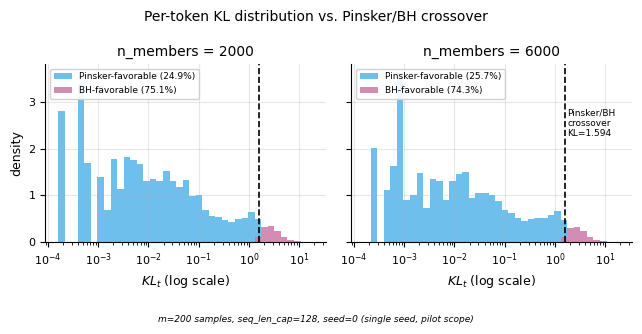

In [40]:
def fig1_kl_distribution_crossover(per_position: pd.DataFrame, crossover_kl: float, out_dir: Path):
    ns = sorted(per_position["n_members"].unique())
    fig, axes = plt.subplots(1, len(ns), figsize=(6.6, 3.0), sharex=True, sharey=True)

    kl_all = per_position["kl_t"].values
    bins = np.logspace(np.log10(kl_all.min() * 0.9), np.log10(kl_all.max() * 1.1), 40)

    for ax, n_members in zip(axes, ns):
        grp = per_position[per_position["n_members"] == n_members]
        below = grp.loc[grp["kl_t"] < crossover_kl, "kl_t"]
        above = grp.loc[grp["kl_t"] >= crossover_kl, "kl_t"]
        pct_below = 100 * len(below) / len(grp)
        pct_above = 100 - pct_below

        ax.hist(below, bins=bins, density=True, color=COLOR_PINSKER, alpha=0.85,
                label=f"Pinsker-favorable ({pct_below:.1f}%)")
        ax.hist(above, bins=bins, density=True, color=COLOR_BH, alpha=0.85,
                label=f"BH-favorable ({pct_above:.1f}%)")
        ax.axvline(crossover_kl, color="black", ls="--", lw=1.2)
        ax.set_xscale("log")
        ax.set_title(f"n_members = {n_members}")
        ax.set_xlabel(r"$KL_t$ (log scale)")
        ax.legend(loc="upper left", fontsize=6.5, framealpha=0.9)

    axes[0].set_ylabel("density")
    ymax = axes[-1].get_ylim()[1]
    axes[-1].text(crossover_kl * 1.1, ymax * 0.75, f"Pinsker/BH\ncrossover\nKL={crossover_kl:.3f}",
                  fontsize=6.5, va="top")

    fig.suptitle("Per-token KL distribution vs. Pinsker/BH crossover", fontsize=10)
    fig.text(0.5, -0.06, CAPTION_NOTE, ha="center", fontsize=6.5, style="italic")
    fig.tight_layout()
    save_fig(fig, "token_fig1_kl_distribution_crossover", out_dir)
    plt.show()


fig1_kl_distribution_crossover(per_position, crossover_kl, OUT_DIR)


## Figure 2 -- KL_t and bh_t vs. position-in-sequence, n_members=2000 vs 6000 overlaid

Two stacked subplots sharing the x-axis (`position_t`, 1-128): top panel is the raw divergence profile (`kl_t`), bottom panel is the per-token bound after the Pinsker/BH transform (`bh_t`). Band = 25th-75th percentile per position.

  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig2_position_profile.pdf
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig2_position_profile.png


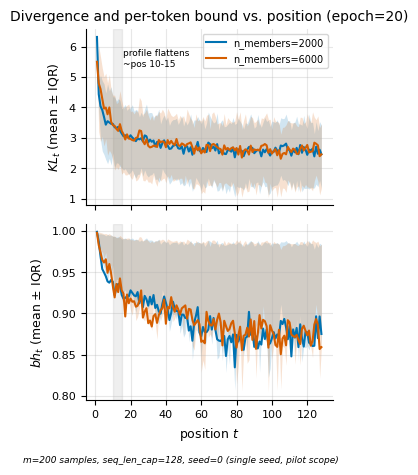

In [41]:
def _position_stats(df: pd.DataFrame, col: str):
    g = df.groupby("position_t")[col]
    return g.mean(), g.quantile(0.25), g.quantile(0.75)


def fig2_position_profile(per_position: pd.DataFrame, out_dir: Path):
    fig, (ax_kl, ax_bh) = plt.subplots(2, 1, figsize=(3.3, 4.6), sharex=True)

    for n_members, grp in per_position.groupby("n_members"):
        color = PALETTE_N_MEMBERS[n_members]

        mean_kl, p25_kl, p75_kl = _position_stats(grp, "kl_t")
        ax_kl.plot(mean_kl.index, mean_kl.values, color=color, lw=1.5, label=f"n_members={n_members}")
        ax_kl.fill_between(mean_kl.index, p25_kl.values, p75_kl.values, color=color, alpha=0.18, lw=0)

        mean_bh, p25_bh, p75_bh = _position_stats(grp, "bh_t")
        ax_bh.plot(mean_bh.index, mean_bh.values, color=color, lw=1.5, label=f"n_members={n_members}")
        ax_bh.fill_between(mean_bh.index, p25_bh.values, p75_bh.values, color=color, alpha=0.18, lw=0)

    for ax in (ax_kl, ax_bh):
        ax.axvspan(10, 15, color="gray", alpha=0.12, zorder=0)

    ax_kl.text(16, ax_kl.get_ylim()[1] * 0.9, "profile flattens\n~pos 10-15", fontsize=6.5, va="top")
    ax_kl.set_ylabel(r"$KL_t$ (mean $\pm$ IQR)")
    ax_bh.set_ylabel(r"$bh_t$ (mean $\pm$ IQR)")
    ax_bh.set_xlabel("position $t$")
    ax_kl.set_title("Divergence and per-token bound vs. position (epoch=20)")
    ax_kl.legend(loc="upper right", fontsize=7)

    fig.text(0.5, -0.015, CAPTION_NOTE, ha="center", fontsize=6.5, style="italic")
    fig.tight_layout()
    save_fig(fig, "token_fig2_position_profile", out_dir)
    plt.show()


fig2_position_profile(per_position, OUT_DIR)


## Figure 3 -- Sequence-level diagnostic: what still varies once the aggregate bound is saturated

`bh_seq_hat` and `tok_bound_hat_capped` are both constant at 1.0 across the entire sweep (confirmed in the inspection cell above) -- this figure deliberately omits them and shows `kl_seq_hat` and `adv_ref_existing` instead, which still vary and remain informative.

  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig3_sequence_level_diagnostic.pdf
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig3_sequence_level_diagnostic.png


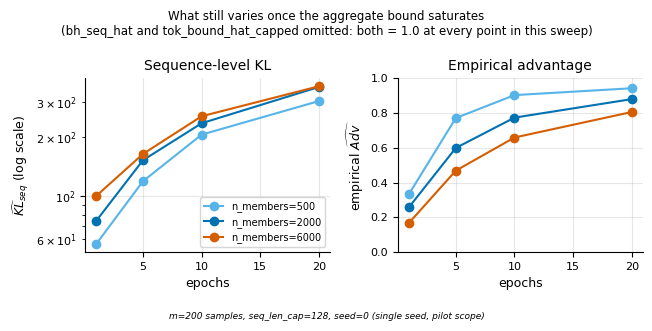

In [42]:
def fig3_sequence_level_diagnostic(bounds: pd.DataFrame, out_dir: Path):
    assert bounds["bh_seq_hat"].nunique() == 1 and bounds["bh_seq_hat"].iloc[0] == 1.0, (
        "Figure 3: bh_seq_hat is not constant at 1.0 -- stop, this contradicts the "
        "inspection-cell finding this figure design relies on."
    )
    assert bounds["tok_bound_hat_capped"].nunique() == 1 and bounds["tok_bound_hat_capped"].iloc[0] == 1.0, (
        "Figure 3: tok_bound_hat_capped is not constant at 1.0 -- stop, this contradicts the "
        "inspection-cell finding this figure design relies on."
    )

    fig, (ax_kl, ax_adv) = plt.subplots(1, 2, figsize=(6.6, 3.0))

    for n_members, grp in bounds.groupby("n_members"):
        grp = grp.sort_values("epochs")
        color = PALETTE_N_MEMBERS[n_members]
        ax_kl.plot(grp["epochs"], grp["kl_seq_hat"], "o-", color=color, label=f"n_members={n_members}")
        ax_adv.plot(grp["epochs"], grp["adv_ref_existing"], "o-", color=color, label=f"n_members={n_members}")

    ax_kl.set_yscale("log")
    ax_kl.set_xlabel("epochs")
    ax_kl.set_ylabel(r"$\widehat{KL}_{seq}$ (log scale)")
    ax_kl.set_title("Sequence-level KL")
    ax_kl.legend(fontsize=7)

    ax_adv.set_ylim(0, 1)
    ax_adv.set_xlabel("epochs")
    ax_adv.set_ylabel(r"empirical $\widehat{Adv}$")
    ax_adv.set_title("Empirical advantage")

    fig.suptitle(
        "What still varies once the aggregate bound saturates\n"
        "(bh_seq_hat and tok_bound_hat_capped omitted: both = 1.0 at every point in this sweep)",
        fontsize=8.5,
    )
    fig.text(0.5, -0.05, CAPTION_NOTE, ha="center", fontsize=6.5, style="italic")
    fig.tight_layout()
    save_fig(fig, "token_fig3_sequence_level_diagnostic", out_dir)
    plt.show()


fig3_sequence_level_diagnostic(bounds, OUT_DIR)


## Figure 4 -- Compression ratio: tok_bound_hat / kl_tok_hat vs. epochs

If the ratio is not monotonically non-increasing in epochs for every `n_members`, the cell raises rather than silently adjusting the figure to fit the expected trend.

  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig4_compression_ratio.pdf
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig4_compression_ratio.png


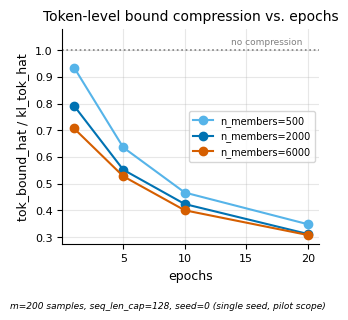

In [43]:
def fig4_compression_ratio(bounds: pd.DataFrame, out_dir: Path):
    df = bounds.copy()
    df["ratio"] = df["tok_bound_hat"] / df["kl_tok_hat"]

    fig, ax = plt.subplots(figsize=(3.3, 3.0))
    for n_members, grp in df.groupby("n_members"):
        grp = grp.sort_values("epochs")

        if not (grp["ratio"].diff().dropna() <= 1e-9).all():
            raise RuntimeError(
                f"Figure 4: ratio is NOT monotonically decreasing for n_members={n_members} "
                f"-- stopping instead of hiding this:\n"
                f"{grp[['epochs', 'ratio']].to_string(index=False)}"
            )

        ax.plot(grp["epochs"], grp["ratio"], "o-", color=PALETTE_N_MEMBERS[n_members],
                label=f"n_members={n_members}")

    ax.axhline(1.0, color="gray", ls=":", lw=1.2)
    ax.set_ylim(top=max(1.08, df["ratio"].max() * 1.08))
    ax.text(df["epochs"].max() * 0.98, 1.015, "no compression", ha="right", va="bottom",
            fontsize=6.5, color="gray")
    ax.set_xlabel("epochs")
    ax.set_ylabel("tok_bound_hat / kl_tok_hat")
    ax.set_title("Token-level bound compression vs. epochs")
    ax.legend(fontsize=7, loc="center right")

    fig.text(0.5, -0.04, CAPTION_NOTE, ha="center", fontsize=6.5, style="italic")
    fig.tight_layout()
    save_fig(fig, "token_fig4_compression_ratio", out_dir)
    plt.show()


fig4_compression_ratio(bounds, OUT_DIR)


## Figure 5 -- Shape-invariance check: does corpus size change the position profile's shape or only its amplitude?

Epochs=20 only (all we have both corpus sizes for). Mean `kl_t` per position for n_members=2000 (x) vs. n_members=6000 (y), one point per position, colored by position with viridis. The observed pattern (hugging y=x vs. offset-but-linear) is computed, not presupposed, and stated in the caption.

Figure 5 stats: r=0.9119  slope=0.9347  intercept=0.2213  mean(y-x)=0.0383
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig5_shape_invariance.pdf
  saved -> c:\Users\JALAL\OneDrive\Documents\MIA_Finetuned_LLMs\token_level\figures\token_fig5_shape_invariance.png


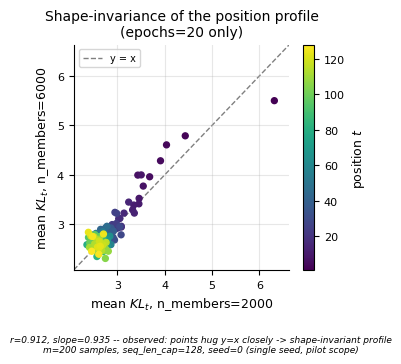

In [44]:
def fig5_shape_invariance(per_position: pd.DataFrame, out_dir: Path):
    mean_2000 = per_position[per_position["n_members"] == 2000].groupby("position_t")["kl_t"].mean()
    mean_6000 = per_position[per_position["n_members"] == 6000].groupby("position_t")["kl_t"].mean()
    positions = mean_2000.index.values
    x, y = mean_2000.values, mean_6000.values

    corr = float(np.corrcoef(x, y)[0, 1])
    slope, intercept = np.polyfit(x, y, 1)
    mean_offset = float(np.mean(y - x))
    print(f"Figure 5 stats: r={corr:.4f}  slope={slope:.4f}  intercept={intercept:.4f}  "
          f"mean(y-x)={mean_offset:.4f}")

    fig, ax = plt.subplots(figsize=(3.6, 3.3))
    lims = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.05]
    ax.plot(lims, lims, color="gray", ls="--", lw=1, label="y = x", zorder=1)

    sc = ax.scatter(x, y, c=positions, cmap="viridis", s=18, zorder=2)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("position $t$")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"mean $KL_t$, n_members=2000")
    ax.set_ylabel(r"mean $KL_t$, n_members=6000")
    ax.set_title("Shape-invariance of the position profile\n(epochs=20 only)")
    ax.legend(loc="upper left", fontsize=7)

    pattern = ("points hug y=x closely -> shape-invariant profile" if abs(slope - 1) < 0.15
               else "points offset from y=x but linear -> shape-preserving amplitude shift")
    fig.text(0.5, -0.08,
              f"r={corr:.3f}, slope={slope:.3f} -- observed: {pattern}\n{CAPTION_NOTE}",
              ha="center", fontsize=6.5, style="italic")
    fig.tight_layout()
    save_fig(fig, "token_fig5_shape_invariance", out_dir)
    plt.show()


fig5_shape_invariance(per_position, OUT_DIR)


In [45]:
import torch
c = torch.load("illustrative_example_cache_epoch20.pt",
               map_location="cpu", weights_only=False)   # weights_only=False required: it holds plain dicts
print(c.keys())
print(c["meta"])

dict_keys(['seqs', 'kl_t', 'pinsker_t', 'bh_t', 'min_t', 'cross_check', 'meta'])
{'n_members': 6000, 'seed': 0, 'epoch': 20, 'C': 40, 'T': 64, 'gen_seed': 0, 'window_len': 32, 'crossover_kl': 1.5936, 'front_load_cutoff': 15}


In [46]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125m")

i = 0
ids = c["seqs"][i]
print(tok.decode(ids))
for t in range(15):
    piece = tok.decode([ids[t + 1].item()])
    print(f"{t:>3} {piece!r:<12} KL={c['kl_t'][i,t]:.4f}  min_bound={c['min_t'][i,t]:.4f}")

<|endoftext|> maramily - home _ re _ nsgs! _ s! _gsg! _ b! _ rtggyuap! _ pzyvngopk!
home re! n'sg worked closely with the new legislation for thetil - enron
communications community this year as we shared over 200
  0 ' mar'       KL=5.5018  min_bound=0.9980
  1 'amily'      KL=11.1970  min_bound=1.0000
  2 ' -'         KL=3.7090  min_bound=0.9877
  3 ' home'      KL=3.6259  min_bound=0.9866
  4 ' _'         KL=5.7519  min_bound=0.9984
  5 ' re'        KL=4.0347  min_bound=0.9911
  6 ' _'         KL=3.5950  min_bound=0.9862
  7 ' ns'        KL=5.2105  min_bound=0.9973
  8 'gs'         KL=10.0359  min_bound=1.0000
  9 '!'          KL=4.9610  min_bound=0.9965
 10 ' _'         KL=1.7709  min_bound=0.9109
 11 ' s'         KL=3.5147  min_bound=0.9850
 12 '!'          KL=2.7774  min_bound=0.9684
 13 ' _'         KL=2.1264  min_bound=0.9385
 14 'gs'         KL=4.5955  min_bound=0.9949


window length      : 32 tokens
sum KL_t           : 111.85 nats
whole-window BH    : 1.0000  (saturated)
whole-window Pinsker: 7.48  (vacuous)
sum per-token min  : 26.66


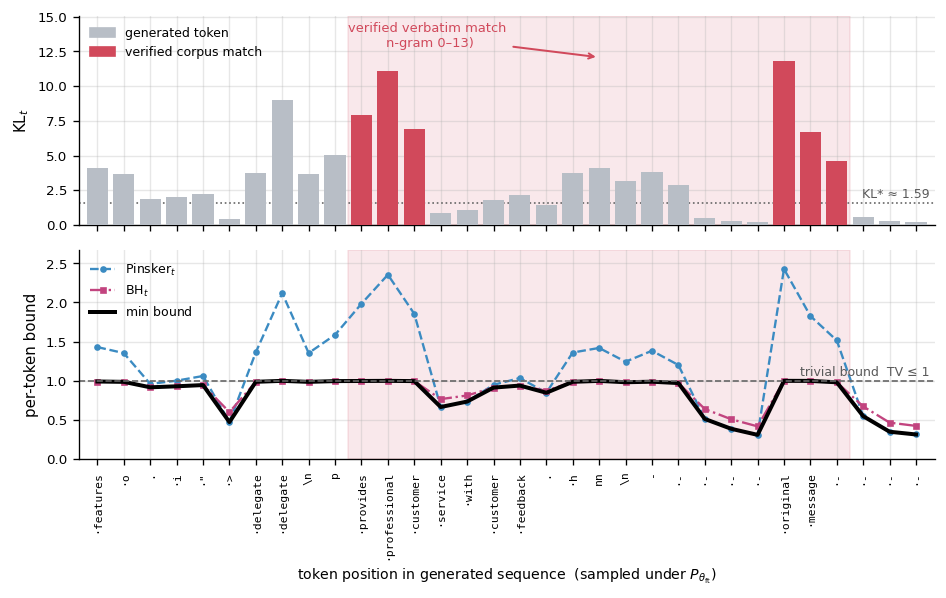

wrote ./fig5_token_strip_example.{pdf,png}


In [47]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

HERE = "./"
CSV = os.path.join(HERE, "selected_example_tokens.csv")
OUTDIR = HERE

C_PINSKER = "#3B8BC2"   # blue  (R1 branch)  -- matches phase-transition fig
C_BH      = "#C2447F"   # magenta/pink (R2 branch)
C_MIN     = "#000000"   # black, bold (the active bound)
C_KL      = "#B8BEC6"   # neutral grey bars
C_MATCH   = "#D1495B"   # warm red, verified memorised span (distinct from palette)
CROSSOVER = 1.5936      # Pinsker/BH crossover in KL (nats)

mpl.rcParams.update({
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def load():
    d = pd.read_csv(CSV).sort_values("local_position").reset_index(drop=True)
    # human-readable token labels: show newline explicitly, keep leading space visible
    def fmt(tok):
        if tok is None:
            return ""
        t = str(tok).replace("\r", "").replace("\n", r"\n")
        t = t.replace(" ", "·")  # middle-dot marks the BPE leading space
        return t if t.strip() else t
    d["label"] = d["token_str_decoded"].map(fmt)
    return d


def matched_span(d):
    """Return (start_idx, end_idx, ngram_range_str) for the verified match, or None."""
    m = d.index[d["is_corpus_match"]].tolist()
    if not m:
        return None
    lo, hi = min(m), max(m)
    ng = d.loc[d["is_corpus_match"], "matched_ngram_length"]
    ng_str = f"{int(ng.min())}–{int(ng.max())}" if ng.min() != ng.max() else f"{int(ng.min())}"
    span_txt = "".join(str(s) for s in d.loc[lo:hi, "token_str_decoded"]).strip()
    return lo, hi, ng_str, span_txt


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUTDIR, f"{name}.{ext}"),
                    bbox_inches="tight", dpi=300)
    print("wrote", os.path.join(OUTDIR, name + ".{pdf,png}"))


# --------------------------------------------------------------------------
# Figure 1 -- token strip (KL bars + bound lines)
# --------------------------------------------------------------------------
def fig_token_strip(d):
    n = len(d)
    x = np.arange(n)
    span = matched_span(d)

    fig, (ax_kl, ax_bd) = plt.subplots(
        2, 1, figsize=(9.2, 4.8), sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.12},
    )

    # shade the verified-match span across both panels
    if span:
        lo, hi, ng_str, span_txt = span
        for ax in (ax_kl, ax_bd):
            ax.axvspan(lo - 0.5, hi + 0.5, color=C_MATCH, alpha=0.12, zorder=0)

    # ---- top: KL_t bars ----
    colors = [C_MATCH if m else C_KL for m in d["is_corpus_match"]]
    ax_kl.bar(x, d["kl_t"], color=colors, width=0.8, zorder=3)
    ax_kl.axhline(CROSSOVER, color="0.4", ls=":", lw=1, zorder=2)
    ax_kl.text(n - 0.5, CROSSOVER + 0.15, "KL* ≈ 1.59",
               ha="right", va="bottom", fontsize=7.5, color="0.35")
    ax_kl.set_ylabel(r"$\mathrm{KL}_t$")
    ax_kl.set_ylim(0, max(d["kl_t"]) * 1.28)

    if span:
        lo, hi, ng_str, span_txt = span
        xc = (lo + hi) / 2.0
        ytop = max(d["kl_t"]) * 1.24
        ax_kl.annotate(
            f"verified verbatim match\n n-gram {ng_str})",
            xy=(xc, d["kl_t"].iloc[lo:hi + 1].max() + 0.3),
            xytext=(xc - 6.5, ytop),
            fontsize=7.8, color=C_MATCH, ha="center", va="top",
            arrowprops=dict(arrowstyle="->", color=C_MATCH, lw=1.2),
        )

    # legend for the bars
    from matplotlib.patches import Patch
    ax_kl.legend(handles=[Patch(color=C_KL, label="generated token"),
                          Patch(color=C_MATCH, label="verified corpus match")],
                 loc="upper left", frameon=False, fontsize=7.5)

    # ---- bottom: the three bounds ----
    ax_bd.plot(x, d["pinsker_t"], color=C_PINSKER, ls="--", lw=1.4,
               marker="o", ms=3, label=r"Pinsker$_t$")
    ax_bd.plot(x, d["bh_t"], color=C_BH, ls="-.", lw=1.4,
               marker="s", ms=3, label=r"BH$_t$")
    ax_bd.plot(x, d["min_t"], color=C_MIN, lw=2.4,
               label=r"$\min$ bound")
    ax_bd.axhline(1.0, color="0.4", ls="--", lw=1)
    ax_bd.text(n - 0.5, 1.02, "trivial bound  TV ≤ 1",
               ha="right", va="bottom", fontsize=7.5, color="0.35")
    ax_bd.set_ylabel("per-token bound")
    ax_bd.set_ylim(0, max(d["pinsker_t"]) * 1.1)
    ax_bd.legend(loc="upper left", frameon=False, fontsize=7.5, ncol=1)

    # ---- shared x tick labels: the decoded tokens ----
    ax_bd.set_xticks(x)
    ax_bd.set_xticklabels(d["label"], rotation=90, fontsize=6.8,
                          fontfamily="monospace")
    ax_bd.set_xlim(-0.7, n - 0.3)
    ax_bd.set_xlabel("token position in generated sequence  "
                     r"(sampled under $P_{\theta_{\mathrm{ft}}}$)", fontsize=8.5)
    
    # plot the figure here first
    plt.show()

    # Save
    save(fig, "fig5_token_strip_example")
    plt.close(fig)



if __name__ == "__main__":
    d = load()
    # quick provenance printout / the contrast number for the caption
    ksum = d["kl_t"].sum()
    print(f"window length      : {len(d)} tokens")
    print(f"sum KL_t           : {ksum:.2f} nats")
    print(f"whole-window BH    : {np.sqrt(1-np.exp(-ksum)):.4f}  (saturated)")
    print(f"whole-window Pinsker: {np.sqrt(ksum/2):.2f}  (vacuous)")
    print(f"sum per-token min  : {d['min_t'].sum():.2f}")
    fig_token_strip(d)
    # fig_heat_strip(d, value="kl_t")               # -> fig6_token_heatstrip_example
    # fig_heat_strip(d, value="min_t",              # bound-valued variant
    #                name="fig6b_token_heatstrip_minbound")

window length      : 32 tokens
sum KL_t           : 111.85 nats
whole-window BH    : 1.0000  (saturated)
whole-window Pinsker: 7.48  (vacuous)
sum per-token min  : 26.66
  matched run idx 10-12  peak KL=11.12  n-gram=None  'provides professional customer'
  matched run idx 26-28  peak KL=11.78  n-gram=11–13  'original message -'


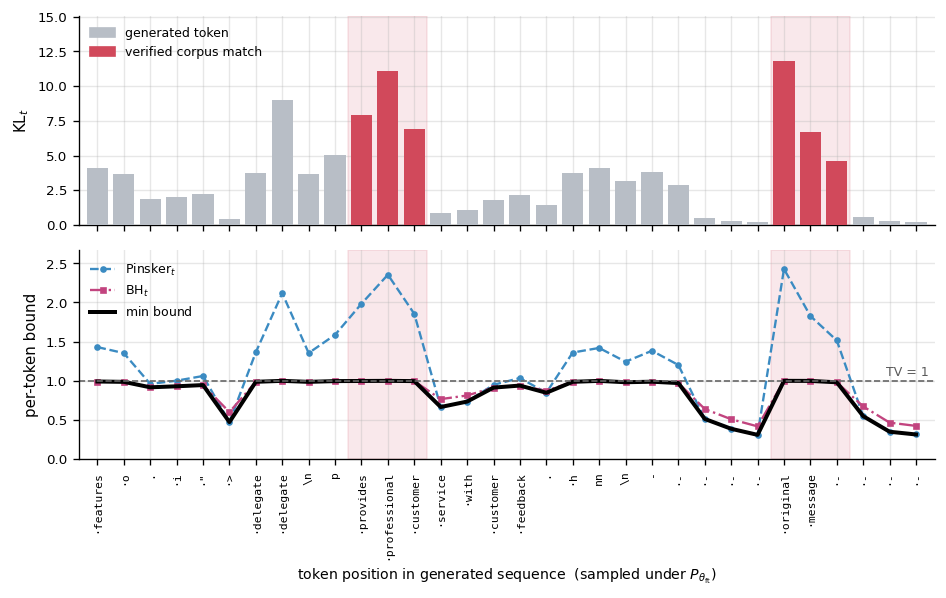

wrote ./fig6_token.{pdf,png}


: 

In [ ]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

HERE = "./"
CSV = os.path.join(HERE, "selected_example_tokens.csv")
OUTDIR = HERE

C_PINSKER = "#3B8BC2"   # blue  (R1 branch)  -- matches phase-transition fig
C_BH      = "#C2447F"   # magenta/pink (R2 branch)
C_MIN     = "#000000"   # black, bold (the active bound)
C_KL      = "#B8BEC6"   # neutral grey bars
C_MATCH   = "#D1495B"   # warm red, verified memorised span (distinct from palette)
CROSSOVER = 1.5936      # Pinsker/BH crossover in KL (nats)
ANNOTATE_ALL = False    # True -> one arrow per matched run, not just the strongest

mpl.rcParams.update({
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def load():
    d = pd.read_csv(CSV).sort_values("local_position").reset_index(drop=True)
    # human-readable token labels: show newline explicitly, keep leading space visible
    def fmt(tok):
        if tok is None:
            return ""
        t = str(tok).replace("\r", "").replace("\n", r"\n")
        t = t.replace(" ", "·")  # middle-dot marks the BPE leading space
        return t if t.strip() else t
    d["label"] = d["token_str_decoded"].map(fmt)
    return d


def matched_runs(d):
    """Contiguous runs of verified corpus matches.

    One entry per run instead of a single min->max span, so a sequence with
    several separated memorised fragments gets several shaded regions rather
    than one block swallowing the non-matching tokens in between.
    """
    flags = d["is_corpus_match"].astype(bool).to_numpy()
    n = len(flags)
    runs, i = [], 0
    while i < n:
        if not flags[i]:
            i += 1
            continue
        j = i
        while j + 1 < n and flags[j + 1]:
            j += 1
        ng = d.loc[i:j, "matched_ngram_length"]
        ng = ng[ng > 0]                      # 0 == no length recorded, don't label it
        if len(ng) == 0:
            ng_str = None
        elif ng.min() == ng.max():
            ng_str = f"{int(ng.min())}"
        else:
            ng_str = f"{int(ng.min())}–{int(ng.max())}"
        runs.append({
            "lo": i, "hi": j, "ng_str": ng_str,
            "peak_kl": float(d.loc[i:j, "kl_t"].max()),
            "text": "".join(str(s) for s in d.loc[i:j, "token_str_decoded"]).strip(),
        })
        i = j + 1
    return runs


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUTDIR, f"{name}.{ext}"),
                    bbox_inches="tight", dpi=300)
    print("wrote", os.path.join(OUTDIR, name + ".{pdf,png}"))


# --------------------------------------------------------------------------
# Figure 1 -- token strip (KL bars + bound lines)
# --------------------------------------------------------------------------
def fig_token_strip(d):
    n = len(d)
    x = np.arange(n)
    runs = matched_runs(d)

    fig, (ax_kl, ax_bd) = plt.subplots(
        2, 1, figsize=(9.2, 4.8), sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.12},
    )

    # shade each verified-match run separately, across both panels
    for r in runs:
        for ax in (ax_kl, ax_bd):
            ax.axvspan(r["lo"] - 0.5, r["hi"] + 0.5, color=C_MATCH, alpha=0.12, zorder=0)

    # ---- top: KL_t bars ----
    colors = [C_MATCH if m else C_KL for m in d["is_corpus_match"]]
    ax_kl.bar(x, d["kl_t"], color=colors, width=0.8, zorder=3)
    # ax_kl.axhline(CROSSOVER, color="0.4", ls=":", lw=1, zorder=2)
    # ax_kl.text(n - 0.5, CROSSOVER + 0.15, "KL* ≈ 1.59",
    #            ha="right", va="bottom", fontsize=7.5, color="0.35")
    ax_kl.set_ylabel(r"$\mathrm{KL}_t$")
    ax_kl.set_ylim(0, max(d["kl_t"]) * 1.28)

    # annotate after the bars so the arrow sits on top of them
    # if runs:
    #     # one arrow per run gets cluttered; by default label only the strongest
    #     to_label = runs if ANNOTATE_ALL else [max(runs, key=lambda r: r["peak_kl"])]
    #     ytop = max(d["kl_t"]) * 1.24
    #     for r in to_label:
    #         xc = (r["lo"] + r["hi"]) / 2.0
    #         txt = "verified verbatim match"
    #         # if r["ng_str"]:
    #         #     txt += f"\n(n-gram {r['ng_str']})"
    #         ax_kl.annotate(
    #             txt,
    #             xy=(xc, r["peak_kl"] + 0.3),
    #             xytext=(min(max(xc - 6.5, 1.0), n - 2.0), ytop),
    #             fontsize=7.8, color=C_MATCH, ha="center", va="top", zorder=5,
    #             arrowprops=dict(arrowstyle="->", color=C_MATCH, lw=1.2 ),
    #         )

    #     # there exist 2 clusters of verified match, I want to see arrows to both of them
    #     for r in runs:
    #         xc = (r["lo"] + r["hi"]) / 2.0
    #         txt = "verified verbatim match"
    #         ax_kl.annotate(
    #             txt,
    #             xy=(xc, r["peak_kl"] + 0.3),
    #             xytext=(min(max(xc - 6.5, 1.0), n - 2.0), ytop),
    #             fontsize=7.8, color=C_MATCH, ha="center", va="top", zorder=5,
    #             arrowprops=dict(arrowstyle="->", color=C_MATCH, lw=1.2),
    #         )

    # legend for the bars
    from matplotlib.patches import Patch
    ax_kl.legend(handles=[Patch(color=C_KL, label="generated token"),
                          Patch(color=C_MATCH, label="verified corpus match")],
                 loc="upper left", frameon=False, fontsize=7.5)

    # ---- bottom: the three bounds ----
    ax_bd.plot(x, d["pinsker_t"], color=C_PINSKER, ls="--", lw=1.4,
               marker="o", ms=3, label=r"Pinsker$_t$")
    ax_bd.plot(x, d["bh_t"], color=C_BH, ls="-.", lw=1.4,
               marker="s", ms=3, label=r"BH$_t$")
    ax_bd.plot(x, d["min_t"], color=C_MIN, lw=2.4,
               label=r"$\min$ bound")
    ax_bd.axhline(1.0, color="0.4", ls="--", lw=1)
    ax_bd.text(n - 0.5, 1.02, "TV = 1",
               ha="right", va="bottom", fontsize=7.5, color="0.35")
    ax_bd.set_ylabel("per-token bound")
    ax_bd.set_ylim(0, max(d["pinsker_t"]) * 1.1)
    ax_bd.legend(loc="upper left", frameon=False, fontsize=7.5, ncol=1)

    # ---- shared x tick labels: the decoded tokens ----
    ax_bd.set_xticks(x)
    ax_bd.set_xticklabels(d["label"], rotation=90, fontsize=6.8,
                          fontfamily="monospace")
    ax_bd.set_xlim(-0.7, n - 0.3)
    ax_bd.set_xlabel("token position in generated sequence  "
                     r"(sampled under $P_{\theta_{\mathrm{ft}}}$)", fontsize=8.5)

    # plot the figure here first
    plt.show()

    # Save
    save(fig, "fig6_token")
    plt.close(fig)



if __name__ == "__main__":
    d = load()
    # quick provenance printout / the contrast number for the caption
    ksum = d["kl_t"].sum()
    print(f"window length      : {len(d)} tokens")
    print(f"sum KL_t           : {ksum:.2f} nats")
    print(f"whole-window BH    : {np.sqrt(1-np.exp(-ksum)):.4f}  (saturated)")
    print(f"whole-window Pinsker: {np.sqrt(ksum/2):.2f}  (vacuous)")
    print(f"sum per-token min  : {d['min_t'].sum():.2f}")
    for r in matched_runs(d):
        print(f"  matched run idx {r['lo']}-{r['hi']}  peak KL={r['peak_kl']:.2f}  "
              f"n-gram={r['ng_str']}  {r['text']!r}")
    fig_token_strip(d)
    # fig_heat_strip(d, value="kl_t")               # -> fig6_token_heatstrip_example
    # fig_heat_strip(d, value="min_t",              # bound-valued variant
    #                name="fig6b_token_heatstrip_minbound")
